# Pemodelan `comb_l_100km` Bahan Bakar Kendaraan Menggunakan Regresi Linear Berganda dengan One-Hot Encoding

**Info Ngopi**

| Anggota | NIM |
|---|---|
| Amadeus Eugene Dirgantara | 0706012410063 |
| Rei Putra Soemanto | 0706012410060 |
| Jason Tio | 0706012410006 |

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype+notebook'
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
sns.set_theme(style='whitegrid', context='notebook')
RNG = 1

## Fase 1: Eksplorasi Data dan Pra-pemrosesan

### 1. Load Raw Data

In [66]:
raw = pd.read_csv('dataset/Fuel_Consumption_2000-2022.csv')
print('Bentuk:', raw.shape)
raw.head()

Bentuk: (22556, 13)


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6000,4,A4,X,9.2000,6.7000,8.1000,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6000,4,M5,X,8.5000,6.5000,7.6000,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2000,6,AS5,Z,12.2000,7.4000,10.0000,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5000,6,A4,Z,13.4000,9.2000,11.5000,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8000,4,A4,X,10.0000,7.0000,8.6000,33,198


In [67]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


Dataset memiliki 22.556 row kendaraan dari tahun 2000 sampai 2022. Column terbagi menjadi ukuran mesin, jumlah silinder, beberapa metrik `comb_l_100km`, emisi dan kategorikal dengan tipe object (merek, kelas kendaraan, transmisi, jenis bahan bakar).

### 2. Memeriksa Nilai yang Hilang

In [68]:
missing = raw.isna().sum().to_frame('n_missing')
missing

,n_missing
YEAR,0
MAKE,0
MODEL,0
VEHICLE CLASS,0
ENGINE SIZE,0
CYLINDERS,0
TRANSMISSION,0
FUEL,0
FUEL CONSUMPTION,0
HWY (L/100 km),0


Tidak ada nilai yang hilang pada kolom mana pun, sehingga tidak diperlukan imputasi.

### 3. Memeriksa Data Duplikat

In [69]:
n_before = len(raw)
raw = raw.drop_duplicates().reset_index(drop=True)
print(f'Menghapus {n_before - len(raw)} baris duplikat. Tersisa: {len(raw)}')

Menghapus 1 baris duplikat. Tersisa: 22555


Satu baris duplikat persis dihapus agar setiap baris merepresentasikan satu observasi unik.

### 4. Identifikasi Variabel Numerik dan Kategorikal

Sebelum membangun model, kita memetakan peran tiap kolom: mana prediktor numerik kontinu dan mana prediktor kategorikal yang akan diolah menggunakan one-hot encoding beserta jumlah nilai uniknya.

In [70]:
ringkasan = raw.dtypes.to_frame('dtype')
ringkasan['n_unique'] = raw.nunique()
ringkasan

,dtype,n_unique
YEAR,int64,23
MAKE,object,87
MODEL,object,4242
VEHICLE CLASS,object,32
ENGINE SIZE,float64,63
CYLINDERS,int64,9
TRANSMISSION,object,30
FUEL,object,5
FUEL CONSUMPTION,float64,228
HWY (L/100 km),float64,152


**Penetapan peran tiap kolom**:
- Prediktor numerik: `engine_size`, `cylinders`, `year`.
- Prediktor kategorikal: `fuel` (5), `vehicle_class` (32), `transmission` (30).

In [71]:
for col in ['FUEL', 'VEHICLE CLASS', 'TRANSMISSION']:
    vals = sorted(raw[col].unique())
    print(f'{col} ({len(vals)} nilai unik):')
    print(' ', vals)
    print()

FUEL (5 nilai unik):
  ['D', 'E', 'N', 'X', 'Z']

VEHICLE CLASS (32 nilai unik):
  ['COMPACT', 'Compact', 'FULL-SIZE', 'Full-size', 'MID-SIZE', 'MINICOMPACT', 'MINIVAN', 'Mid-size', 'Minicompact', 'Minivan', 'PICKUP TRUCK - SMALL', 'PICKUP TRUCK - STANDARD', 'Pickup truck: Small', 'Pickup truck: Standard', 'SPECIAL PURPOSE VEHICLE', 'STATION WAGON - MID-SIZE', 'STATION WAGON - SMALL', 'SUBCOMPACT', 'SUV', 'SUV - SMALL', 'SUV - STANDARD', 'SUV: Small', 'SUV: Standard', 'Special purpose vehicle', 'Station wagon: Mid-size', 'Station wagon: Small', 'Subcompact', 'TWO-SEATER', 'Two-seater', 'VAN - CARGO', 'VAN - PASSENGER', 'Van: Passenger']

TRANSMISSION (30 nilai unik):
  ['A10', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'AM5', 'AM6', 'AM7', 'AM8', 'AM9', 'AS10', 'AS4', 'AS5', 'AS6', 'AS7', 'AS8', 'AS9', 'AV', 'AV1', 'AV10', 'AV6', 'AV7', 'AV8', 'M4', 'M5', 'M6', 'M7']



**Observasi nilai kategori (sebelum normalisasi)**:
- `FUEL` berisi 5 kode (D, E, N, X, Z) yang akan ditampilkan sebagai "definisi (kode)", mis. `Regular gasoline (X)`, agar nama deskriptif dan kode asli dataset sama-sama terbaca.
- `VEHICLE CLASS` memuat label yang sama dengan format berbeda, baik kapitalisasi maupun pemisah (` - ` vs `: `), misalnya `SUV - SMALL` dan `SUV: Small`. Keduanya perlu disamakan agar tidak terhitung sebagai kelas berbeda. (Kelas kendaraan tak punya kode tersendiri, jadi label tetap berupa nama yang sudah dirapikan.)
- `TRANSMISSION` menggabungkan tipe (A, AM, AS, AV, M) dan jumlah gigi (3 sampai 10) dalam satu kode, sehingga akan dipisah menjadi dua fitur: tipe dan jumlah gigi. Tipe juga diberi label "definisi (kode)", mis. `Automatic (A)` dan `Continuously variable (AV)`. Pengecualian untuk "AV" yang merupakan *continuously variable transmission* di mana rasio giginya kontinu, bukan bilangan bulat, sehingga tidak memiliki jumlah gigi yang terdefinisi dan diberi nilai 0.

### 5. Membangun Kerangka Analisis

 Menyiapkan kerangka data yang konsisten untuk dilakukan analisis: memilih kolom yang relevan, menyeragamkan nama kolom menjadi `snake_case`, merapikan label kategori, memecah `transmission` menjadi tipe transmisi dan jumlah gigi, dan menetapkan peran tiap kolom sebagai prediktor numerik, prediktor kategorikal, atau target.

In [72]:
df = raw[['ENGINE SIZE', 'CYLINDERS', 'YEAR', 'FUEL', 'VEHICLE CLASS', 'TRANSMISSION', 'COMB (L/100 km)']].rename(
    columns={
        'ENGINE SIZE': 'engine_size',
        'CYLINDERS': 'cylinders',
        'YEAR': 'year',
        'FUEL': 'fuel',
        'VEHICLE CLASS': 'vehicle_class',
        'TRANSMISSION': 'transmission',
        'COMB (L/100 km)': 'comb_l_100km',
    }
).reset_index(drop=True)

df['vehicle_class'] = (df['vehicle_class'].str.upper()
                       .str.replace(r'\s*[-:]\s*', ' ', regex=True).str.strip())

fuel_names = {'X': 'Regular gasoline (X)', 'Z': 'Premium gasoline (Z)', 'D': 'Diesel (D)',
              'E': 'Ethanol E85 (E)', 'N': 'Natural gas (N)'}
df['fuel'] = df['fuel'].str.upper().str.strip().map(fuel_names)

trans_code = df['transmission'].str.extract(r'^([A-Z]+)')[0]
gears = df['transmission'].str.extract(r'(\d+)')[0].astype(float)
df['n_gears'] = gears.where(trans_code != 'AV', other=0).fillna(0).astype(int)
trans_names = {'A': 'Automatic (A)', 'AM': 'Automated manual (AM)',
               'AS': 'Automatic with select shift (AS)', 'AV': 'Continuously variable (AV)',
               'M': 'Manual (M)'}
df['transmission_type'] = trans_code.map(trans_names)
df = df.drop(columns='transmission')

num_cols = ['engine_size', 'cylinders', 'year', 'n_gears']
cat_cols = ['fuel', 'vehicle_class', 'transmission_type']
target = 'comb_l_100km'

print('Kategori tiap prediktor kategorikal:')
for col in cat_cols:
    print(f'  {col:18s}: {df[col].nunique()}')
print('n_gears unik:', sorted(df['n_gears'].unique()))
df.head()

Kategori tiap prediktor kategorikal:
  fuel              : 5
  vehicle_class     : 17
  transmission_type : 5
n_gears unik: [np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,engine_size,cylinders,year,fuel,vehicle_class,comb_l_100km,n_gears,transmission_type
0,1.6000,4,2000,Regular gasoline (X),COMPACT,8.1000,4,Automatic (A)
1,1.6000,4,2000,Regular gasoline (X),COMPACT,7.6000,5,Manual (M)
2,3.2000,6,2000,Premium gasoline (Z),MID SIZE,10.0000,5,Automatic with select shift (AS)
3,3.5000,6,2000,Premium gasoline (Z),MID SIZE,11.5000,4,Automatic (A)
4,1.8000,4,2000,Regular gasoline (X),SUBCOMPACT,8.6000,4,Automatic (A)


- Prediktor numerik: `engine_size`, `cylinders`, `year`, dan `n_gears` (dari pemisahan transmisi).
- Prediktor kategorikal: `fuel`, `vehicle_class`, dan `transmission_type`.
- Kode bahan bakar dan tipe transmisi ditampilkan sebagai "definisi (kode)", misal `Regular gasoline (X)` dan `Automatic (A)`, agar nama deskriptif dan kode asli sama-sama terlihat.
- `vehicle_class` disamakan kapitalisasi dan pemisahnya (contoh: "SUV - SMALL" dan "SUV: Small" disamakan jadi "SUV SMALL"). Setelah dirapikan, jumlah kelas menyusut dari 32 menjadi 17.
- `transmission` dipisah menjadi `transmission_type` (A/AM/AS/AV/M) dan `n_gears`. CVT (tipe AV) tidak memiliki gigi tetap, sehingga `n_gears = 0`.

### 6. Statistik Deskriptif

Sebelum pemodelan, distribusi tiap variabel diringkas untuk memahami skala, pusat, dan sebaran prediktor numerik serta frekuensi tiap kategori. 

In [73]:
df[num_cols + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
engine_size,22555.0000,3.3566,1.3354,0.8000,2.3000,3.0000,4.2000,8.4000
cylinders,22555.0000,5.8540,1.8196,2.0000,4.0000,6.0000,8.0000,16.0000
year,22555.0000,2011.5550,6.2979,2000.0000,2006.0000,2012.0000,2017.0000,2022.0000
n_gears,22555.0000,5.6354,1.9566,0.0000,5.0000,6.0000,6.0000,10.0000
comb_l_100km,22555.0000,11.0341,2.9108,3.6000,9.1000,10.6000,12.7000,26.1000


In [74]:
for col in cat_cols:
    print(f'== {col} ({df[col].nunique()} kategori) ==')
    print(df[col].value_counts().head(6).to_string())
    print()

== fuel (5 kategori) ==
fuel
Regular gasoline (X)    11822
Premium gasoline (Z)     9315
Ethanol E85 (E)          1071
Diesel (D)                314
Natural gas (N)            33

== vehicle_class (17 kategori) ==
vehicle_class
COMPACT                  3127
MID SIZE                 2960
SUV                      2639
PICKUP TRUCK STANDARD    2204
SUBCOMPACT               2010
SUV SMALL                1756

== transmission_type (5 kategori) ==
transmission_type
Automatic (A)                       8690
Automatic with select shift (AS)    6736
Manual (M)                          4844
Continuously variable (AV)          1207
Automated manual (AM)               1078



**Ringkasan distribusi**:
- Ukuran mesin berkisar sekitar 1 sampai 8 L, silinder terpusat di 4/6/8, tahun tersebar merata 2000 sampai 2022, dan jumlah gigi berkisar 0 (CVT) sampai 10.
- Jenis bahan bakar paling banyak Regular gasoline dan Premium gasoline, sementara tipe transmisi tersebar pada lima kategori (otomatis, manual, dan variannya).

### 7. Pair Plot Variabel Numerik

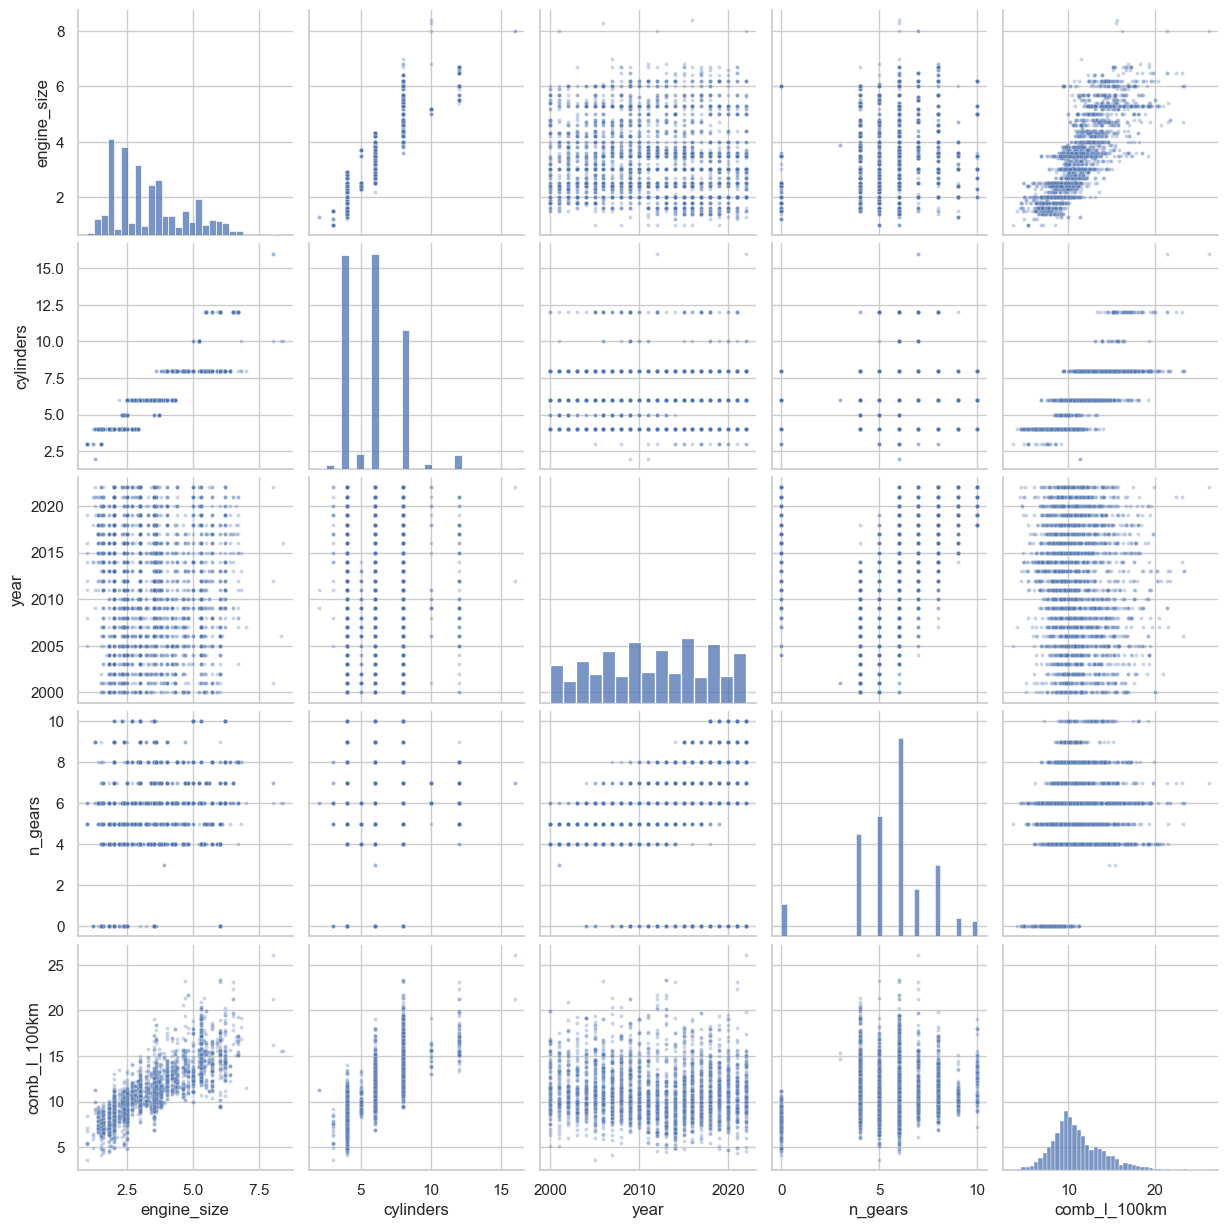

In [75]:
num_pair = num_cols + [target]
samp = df[num_pair].sample(n=min(3000, len(df)), random_state=1)
sns.pairplot(samp, diag_kind='hist', plot_kws={'s': 8, 'alpha': 0.3})
plt.show()

**Pembacaan pair plot**:
- `engine_size`, `cylinders`, dan `comb_l_100km` saling menampilkan pola menanjak yang jelas, konsisten dengan korelasi kuat di bagian 9.
- `cylinders` dan `n_gears` bernilai discrete, sehingga scatter plot membentuk pola vertikal, bukan kontinu.
- `year` menyebar hampir datar terhadap `comb_l_100km`, sesuai korelasinya yang mendekati nol.
- Hubungan dengan `comb_l_100km` tampak mendekati garis lurus, mendukung pemakaian korelasi Pearson dan model linear.

### 8. Distribusi `comb_l_100km` per Kategori

Sebelum melakukan one-hot encoding, kita memeriksa apakah setiap variabel kategorikal benar-benar memiliki dampak terhadap nilai `comb_l_100km`. Jika terdapat pergeseran median `comb_l_100km` antar kategori, maka variabel itu benar-benar mengandung informasi yang layak dipertimbangkan dalam model. 

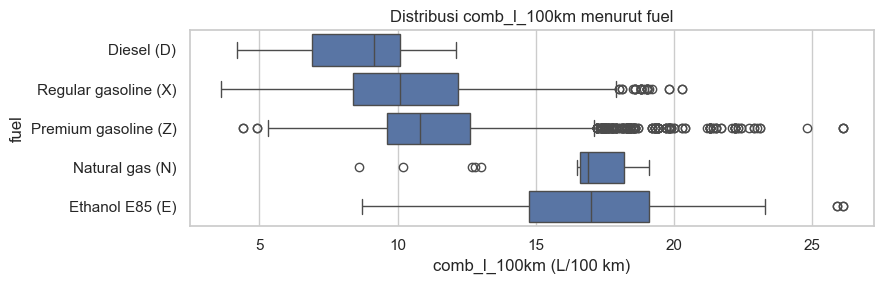

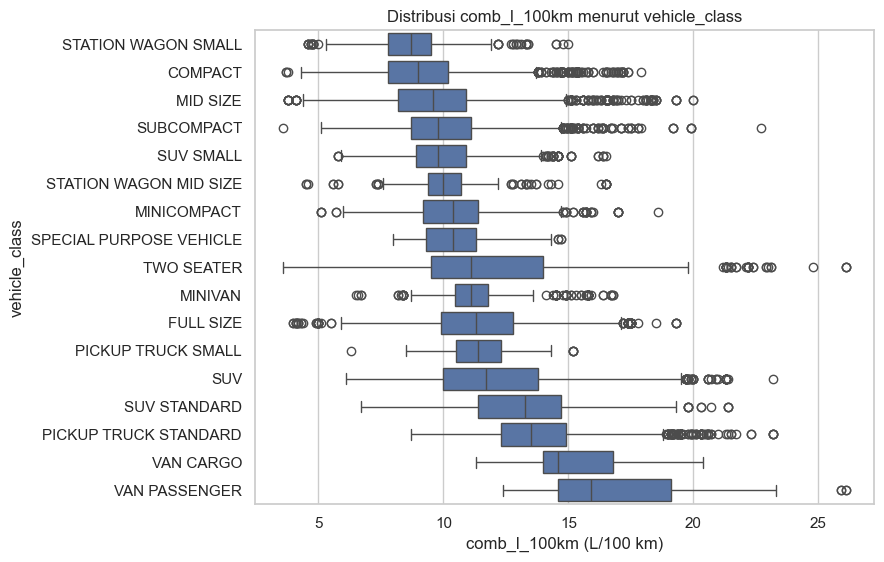

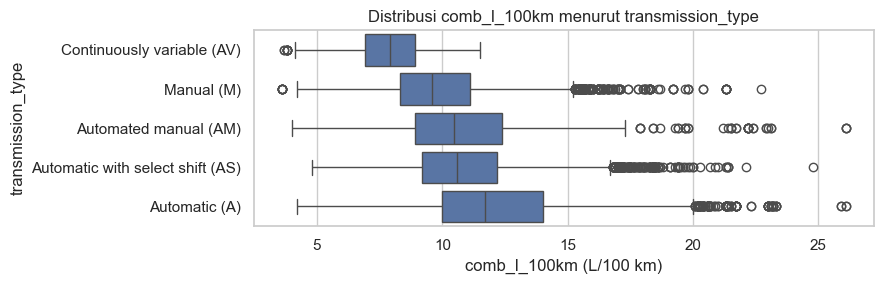

In [76]:
for col in cat_cols:
    order = df.groupby(col)['comb_l_100km'].median().sort_values().index
    plt.figure(figsize=(9, max(3.0, 0.34 * len(order))))
    sns.boxplot(data=df, y=col, x='comb_l_100km', order=order, orient='h')
    plt.title(f'Distribusi comb_l_100km menurut {col}')
    plt.xlabel('comb_l_100km (L/100 km)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Interpretasi boxplot**:
- Ketiga faktor kategorikal menunjukkan pergeseran median yang sistematis antar kategori.
- Jenis bahan bakar Diesel paling hemat, sedangkan Ethanol (E85) dan Natural Gas paling boros.
- Kelas kendaraan menanjak dari sedan kecil ke van dan pickup.
- Tipe transmisi memperlihatkan perbedaan yang lebih landai namun sistematis antar lima tipe.

### 9. Matriks Korelasi Pearson

Korelasi Pearson mengukur kekuatan hubungan linear antar variabel numerik. Variabel kategorikal tidak disertakan di sini karena korelasi hanya bermakna untuk besaran numerik.

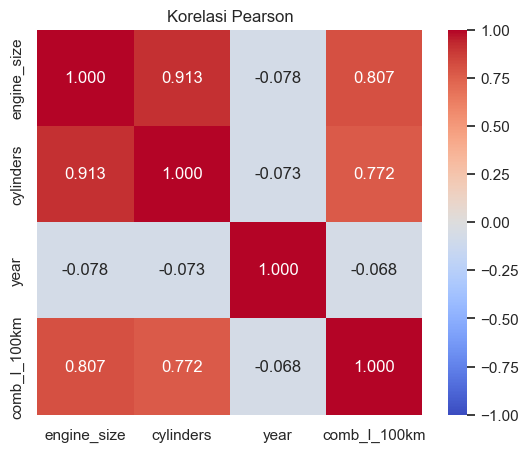

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9134,-0.0777,0.8073
cylinders,0.9134,1.0000,-0.0725,0.7716
year,-0.0777,-0.0725,1.0000,-0.0679
comb_l_100km,0.8073,0.7716,-0.0679,1.0000


In [77]:
num_for_corr = ['engine_size', 'cylinders', 'year', target]
pearson = df[num_for_corr].corr(method='pearson')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(pearson, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Korelasi Pearson')
plt.show()
pearson

Kolom p-value pada tabel di bawah valid secara teknis tetapi tidak informatif pada $n$ sebesar ini, sehingga bukan dasar keputusan. Uji p-value hanya menanyakan apakah korelasi populasi tepat nol, dan karena statistik ujinya membesar seiring $n$, pada $n \approx 22{,}555$ korelasi sekecil apa pun sudah cukup untuk menolak nol. Akibatnya hampir semua pasangan otomatis signifikan ($p \approx 0$) dan p-value tidak dapat membedakan korelasi yang berarti dari yang dapat diabaikan.

Sebagai alternatif, kita menghitung confidence interval (CI 95%) dari koefisien $r$. CI dihitung dengan transformasi Fisher z untuk menstabilisasi variance akibat sampling nilai $r$ yang cenderung skewed kembali menjadi mendekati normal, dengan asumsi bahwa distribusi data awal sudah cukup mendekati normai bivariat.

**Hipotesis** ($\rho$ adalah korelasi populasi, diestimasi oleh $r$ pada sampel)
- $H_0: |\rho| \le 0.1$ (korelasi dianggap tidak signifikan dan tidak infromatif)
- $H_1: |\rho| > 0.1$ (korelasi dianggap signifikan dan informatif)

**Aturan keputusan dengan CI 95%**
- Jika seluruh CI di luar interval $[-0.1, 0.1]$, tolak $H_0$. Korelasi dianggap signifikan dan informatif.
- Jika seluruh CI di dalam interval $[-0.1, 0.1]$, dukung $H_0$. Korelasi dianggap tidak signifikan dan tidak informatif.
- Jika CI memotong batas $0.1$, hasilnya tidak meyakinkan.

In [78]:
n_corr = len(df)

def putusan(lo, hi):
    if lo > 0.1 or hi < -0.1:
        return 'Signifikan'
    if lo >= -0.1 and hi <= 0.1:
        return 'Tidak Signifikan'
    return 'Tidak Meyakinkan'

rows = []
for i, a in enumerate(num_for_corr):
    for b in num_for_corr[i + 1:]:
        res = stats.pearsonr(df[a], df[b])
        r = res.statistic
        lo, hi = res.confidence_interval(0.95)
        rows.append({'Pasangan': f'{a} ~ {b}', 'r': r,
                     'p_value': res.pvalue, 'CI_bawah': lo, 'CI_atas': hi,
                     'Putusan': putusan(lo, hi)})
pearson_eff = pd.DataFrame(rows).set_index('Pasangan')

tampil = pearson_eff.copy()
tampil['p_value'] = tampil['p_value'].map(lambda x: f'{x:.1e}')
for col in ['r', 'CI_bawah', 'CI_atas']:
    tampil[col] = tampil[col].round(4)
tampil

,r,p_value,CI_bawah,CI_atas,Putusan
Pasangan,,,,,
engine_size ~ cylinders,0.9134,0.0e+00,0.9112,0.9155,Signifikan
engine_size ~ year,-0.0777,1.4e-31,-0.0907,-0.0648,Tidak Signifikan
engine_size ~ comb_l_100km,0.8073,0.0e+00,0.8027,0.8118,Signifikan
cylinders ~ year,-0.0725,1.1e-27,-0.0855,-0.0595,Tidak Signifikan
cylinders ~ comb_l_100km,0.7716,0.0e+00,0.7662,0.7768,Signifikan
year ~ comb_l_100km,-0.0679,1.8e-24,-0.0809,-0.0549,Tidak Signifikan


**Pembacaan korelasi Pearson**:
- `engine_size` ($r = 0.81$) dan `cylinders` ($r = 0.77$) berkorelasi linear positif yang kuat dengan `comb_l_100km`. CI 95%-nya jauh di luar batas $0.1$, sehingga $H_0$ ditolak: korelasinya berarti.
- `engine_size` dan `cylinders` sangat collinear ($r = 0.91$), menandakan multicollinearity.
- `year` tak berkorelasi: $r = -0.068$, CI $[-0.081, -0.055]$ seluruhnya di dalam interval $[-0.1, 0.1]$, sehingga $H_0$ didukung: korelasinya dapat diabaikan. Yang menentukan adalah jarak CI ke batas $0.1$, bukan ke nol.
- Kolom p-value semua $\approx 0$, tetapi itu merupakan efek samping dari $n$ besar, jadi dilaporkan sebagai pelengkap dan bukan dasar putusan.
- Validitas: pembacaan ini menggunakan pengandaian hubungan linear (dikonfirmasi di bagian 11) dan peka terhadap outlier (sebaran tiap variabel sudah ditinjau di bagian 6 dan 8). `n_gears` tidak disertakan karena CVT diberi nilai $0$ sebagai konvensi sehingga korelasi mentahnya menyesatkan.

### 10. Matriks Korelasi Spearman

Korelasi Spearman mengukur kekuatan hubungan *monoton* antar variabel numerik karena dihitung pada peringkat (rank), sehingga lebih robust terhadap outlier dan tidak mengandaikan bentuk hubungan yang lurus.

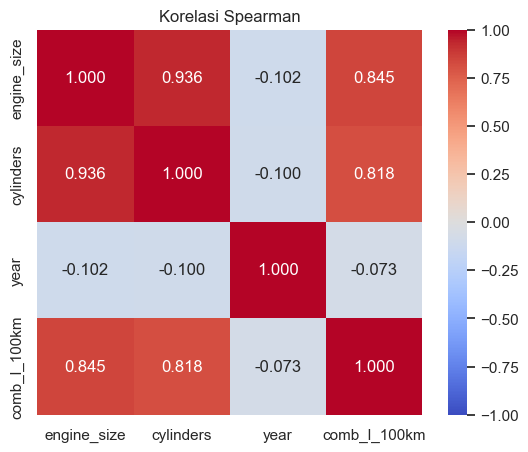

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9357,-0.1020,0.8449
cylinders,0.9357,1.0000,-0.0998,0.8176
year,-0.1020,-0.0998,1.0000,-0.0732
comb_l_100km,0.8449,0.8176,-0.0732,1.0000


In [79]:
spearman = df[num_for_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(spearman, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Korelasi Spearman')
plt.show()
spearman

Sama seperti bagian Pearson, kolom p-value valid tetapi tidak informatif pada $n$ sebesar ini sehingga bukan dasar keputusan karena yang dibaca adalah magnitudo dan confidence interval (CI 95%). CI Spearman juga dihitung menggunakan transformasi Fisher z.

**Hipotesis** ($\rho_S$ adalah korelasi peringkat populasi)
- $H_0: |\rho_S| \le 0.1$ (asosiasi monoton dianggap tidak signifikan dan tidak informatif)
- $H_1: |\rho_S| > 0.1$ (asosiasi monoton dianggap signifikan dan informatif)

**Aturan keputusan dengan CI 95%**
- Seluruh CI di luar interval $[-0.1, 0.1]$: tolak $H_0$. Asosiasi monoton dianggap signifikan dan informatif.
- Seluruh CI di dalam interval $[-0.1, 0.1]$: dukung $H_0$. Asosiasi monoton dianggap tidak signifikan dan tidak informatif.

In [80]:
def spearman_ci(rho, n, alpha=0.05):
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt((1 + rho ** 2 / 2) / (n - 3))
    zf = np.arctanh(rho)
    return np.tanh(zf - z * se), np.tanh(zf + z * se)

def putusan(lo, hi):
    if lo > 0.1 or hi < -0.1:
        return 'Signifikan'
    if lo >= -0.1 and hi <= 0.1:
        return 'Tidak Signifikan'
    return 'Tidak Meyakinkan'

n_sp = len(df)
rows = []
for i, a in enumerate(num_for_corr):
    for b in num_for_corr[i + 1:]:
        res = stats.spearmanr(df[a], df[b])
        lo, hi = spearman_ci(res.statistic, n_sp)
        rows.append({'Pasangan': f'{a} ~ {b}', 'rho': res.statistic,
                     'p_value': res.pvalue, 'CI_bawah': lo, 'CI_atas': hi,
                     'Putusan': putusan(lo, hi)})
spearman_eff = pd.DataFrame(rows).set_index('Pasangan')

tampil = spearman_eff.copy()
tampil['p_value'] = tampil['p_value'].map(lambda x: f'{x:.1e}')
for col in ['rho', 'CI_bawah', 'CI_atas']:
    tampil[col] = tampil[col].round(4)
tampil

,rho,p_value,CI_bawah,CI_atas,Putusan
Pasangan,,,,,
engine_size ~ cylinders,0.9357,0.0e+00,0.9337,0.9376,Signifikan
engine_size ~ year,-0.1020,3.5e-53,-0.1149,-0.0890,Tidak Meyakinkan
engine_size ~ comb_l_100km,0.8449,0.0e+00,0.8405,0.8492,Signifikan
cylinders ~ year,-0.0998,5.5e-51,-0.1127,-0.0868,Tidak Meyakinkan
cylinders ~ comb_l_100km,0.8176,0.0e+00,0.8125,0.8225,Signifikan
year ~ comb_l_100km,-0.0732,3.4e-28,-0.0862,-0.0602,Tidak Signifikan


**Pembacaan korelasi Spearman**:
- `engine_size ~ comb` ($\rho_S = 0.84$) dan `cylinders ~ comb` ($\rho_S = 0.82$): asosiasi monoton positif kuat, CI jauh di luar $0.1$, sehingga $H_0$ ditolak (berarti).
- `engine_size` dan `cylinders` sangat monoton sejalan ($\rho_S = 0.94$), menegaskan kolinearitas yang sama seperti pada Pearson.
- `year ~ comb` ($\rho_S = -0.07$, CI $[-0.09, -0.06]$) seluruhnya di dalam $[-0.1, 0.1]$: dapat diabaikan, konsisten dengan keputusan membuang `year` di bagian 12.
- `engine_size ~ year` dan `cylinders ~ year` ($\rho_S \approx -0.10$) berada di batas: CI memotong $-0.1$ sehingga tidak meyakinkan, sedikit lebih kuat daripada Pearson tetapi tetap kecil.
- Kolom p-value semua $\approx 0$ sebagai efek samping dari $n$ besar, jadi hanya pelengkap.

### 11. Perbandingan Korelasi Pearson vs Spearman

Pearson mengukur hubungan *linear*, Spearman mengukur hubungan *monoton*. Membandingkan keduanya menjadi penyaring linearitas: bila berdekatan, hubungan monotonnya nyaris lurus sehingga Pearson sah ditafsirkan sebagai kekuatan linear. Bila Spearman jauh lebih besar, ada kelengkungan monoton yang membuat Pearson *underestimate*. Ini penyaring informal, bukan uji formal.

In [81]:
banding = pd.DataFrame({
    'Pearson_r': pearson_eff['r'],
    'Spearman_rho': spearman_eff['rho'],
})
banding['selisih (Spearman - Pearson)'] = banding['Spearman_rho'] - banding['Pearson_r']
banding.sort_values('selisih (Spearman - Pearson)', key=abs, ascending=False).round(4)

,Pearson_r,Spearman_rho,selisih (Spearman - Pearson)
Pasangan,,,
cylinders ~ comb_l_100km,0.7716,0.8176,0.0460
engine_size ~ comb_l_100km,0.8073,0.8449,0.0376
cylinders ~ year,-0.0725,-0.0998,-0.0272
engine_size ~ year,-0.0777,-0.1020,-0.0242
engine_size ~ cylinders,0.9134,0.9357,0.0223
year ~ comb_l_100km,-0.0679,-0.0732,-0.0053


**Pembacaan perbandingan**:
- Untuk pasangan terhadap target, Spearman sedikit di atas Pearson (`engine_size ~ comb_l_100km` selisih $+0.04$, `cylinders ~ comb_l_100km` selisih $+0.05$). Selisih kecil dan positif ini menandakan kelengkungan monoton yang sangat ringan: hubungan naik konsisten namun tidak persis lurus, jadi Pearson hanya sedikit *underestimate* dan tetap sah sebagai ringkasan kekuatan linear.
- Tidak ada pasangan dengan selisih besar, sehingga tidak ada kelengkungan monoton yang berarti.
- Penyaring ini hanya menangkap kelengkungan monoton. Karena itu linearitas tetap diperiksa secara visual lewat plot residual (bagian 18) dan diputuskan lewat perbandingan model linear vs polinomial (bagian 15): suku `engine_size`$^2$ ternyata tidak menambah $R^2$ test, jadi model linear yang dipakai.

In [82]:
df

,engine_size,cylinders,year,fuel,vehicle_class,comb_l_100km,n_gears,transmission_type
0,1.6000,4,2000,Regular gasoline (X),COMPACT,8.1000,4,Automatic (A)
1,1.6000,4,2000,Regular gasoline (X),COMPACT,7.6000,5,Manual (M)
2,3.2000,6,2000,Premium gasoline (Z),MID SIZE,10.0000,5,Automatic with select shift (AS)
3,3.5000,6,2000,Premium gasoline (Z),MID SIZE,11.5000,4,Automatic (A)
4,1.8000,4,2000,Regular gasoline (X),SUBCOMPACT,8.6000,4,Automatic (A)
...,...,...,...,...,...,...,...,...
22550,2.0000,4,2022,Premium gasoline (Z),SUV SMALL,9.4000,8,Automatic with select shift (AS)
22551,2.0000,4,2022,Premium gasoline (Z),SUV SMALL,9.4000,8,Automatic with select shift (AS)
22552,2.0000,4,2022,Premium gasoline (Z),SUV SMALL,9.9000,8,Automatic with select shift (AS)
22553,2.0000,4,2022,Premium gasoline (Z),SUV STANDARD,10.1000,8,Automatic with select shift (AS)


## Seleksi Fitur

### 12. Penetapan Himpunan Fitur

**Keputusan himpunan fitur (berdasarkan temuan Fase 1)**:
- `engine_size` dan `cylinders`: keduanya dipertahankan. Masing-masing berkorelasi kuat dengan `comb_l_100km` (Pearson $\approx 0.81$ dan $\approx 0.77$), dan karena tidak redundan sempurna ($r \approx 0.91$, bukan $1$) `cylinders` masih bisa menyumbang kontribusi dalam prediksi diluar `engine_size`. Kolinieritas yang tinggi membuat nilai standard error melonjak sehingga koefisien tidak bisa ditafsirkan sendiri-sendiri, tetapi tidak menurunkan daya prediksi selama korelasi antar-keduanya tetap berlaku pada data baru.
- `engine_size` (kandidat suku kuadratik): karena perbandingan Pearson dan Spearman (bagian 11) menandai kelengkungan kecil pada hubungan `engine_size` dengan `comb_l_100km`, suku `engine_size`$^2$ diuji sebagai kandidat. Apakah ia benar-benar dipakai diputuskan lewat perbandingan model linear vs polinomial pada data test di bagian 15.
- `year`: dibuang. Korelasi marginalnya dengan `comb_l_100km` mendekati nol ($|r| < 0.07$), praktis tidak menyumbang daya prediksi.
- `n_gears`: dipertahankan karena boxplot menunjukkan transmisi berkaitan dengan `comb_l_100km` (CVT $= 0$ sesuai konvensi).
- `fuel`, `vehicle_class`, `transmission_type`: dipertahankan karena boxplot memperlihatkan pergeseran median yang sistematis antar kategori dan akan diolah menggunakan one-hot encoding pada langkah berikutnya.

Kolinieritas `engine_size` dan `cylinders` sudah cukup terbaca dari matriks korelasi Pearson, sehingga tidak diperlukan diagnostik tambahan.

In [83]:
df = df.drop(columns='year')
num_cols = ['engine_size', 'cylinders', 'n_gears']
features = num_cols + cat_cols

print('Fitur final yang dipertahankan:')
print('  numerik     :', num_cols)
print('  kategorikal :', cat_cols)
print('  dibuang     : year')
print('  target      :', target)
df.head()

Fitur final yang dipertahankan:
  numerik     : ['engine_size', 'cylinders', 'n_gears']
  kategorikal : ['fuel', 'vehicle_class', 'transmission_type']
  dibuang     : year
  target      : comb_l_100km


,engine_size,cylinders,fuel,vehicle_class,comb_l_100km,n_gears,transmission_type
0,1.6000,4,Regular gasoline (X),COMPACT,8.1000,4,Automatic (A)
1,1.6000,4,Regular gasoline (X),COMPACT,7.6000,5,Manual (M)
2,3.2000,6,Premium gasoline (Z),MID SIZE,10.0000,5,Automatic with select shift (AS)
3,3.5000,6,Premium gasoline (Z),MID SIZE,11.5000,4,Automatic (A)
4,1.8000,4,Regular gasoline (X),SUBCOMPACT,8.6000,4,Automatic (A)


### 13. One-Hot Encoding

Variabel kategorikal diubah menjadi kolom indikator 0/1. Untuk faktor dengan k kategori dibuat k-1 kolom, menyisakan satu kategori sebagai referensi untuk menghindari dummy variable trap (kolinieritas sempurna dengan konstanta).

In [84]:
ref_cat = {'fuel': 'Diesel (D)', 'vehicle_class': 'COMPACT', 'transmission_type': 'Automatic (A)'}
df_encoded = pd.get_dummies(df, columns=cat_cols)
df_encoded = df_encoded.drop(columns=[f'{c}_{ref_cat[c]}' for c in cat_cols])
dummy_cols = [c for c in df_encoded.columns if c.startswith(tuple(pre + '_' for pre in cat_cols))]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)
df_encoded['engine_size_sq'] = df_encoded['engine_size'] ** 2
feature_cols = num_cols + dummy_cols

print('Dimensi sebelum encoding :', df.shape)
print('Dimensi sesudah encoding :', df_encoded.shape)
print('Jumlah kolom dummy       :', len(dummy_cols))
print('Total fitur (model linear):', len(feature_cols))
print('Disiapkan                :', 'engine_size_sq (untuk perbandingan model di bagian 15)')
print()
for col in cat_cols:
    print(f'Kategori referensi {col:18s}: {ref_cat[col]}')
df_encoded.head()

Dimensi sebelum encoding : (22555, 7)
Dimensi sesudah encoding : (22555, 29)
Jumlah kolom dummy       : 24
Total fitur (model linear): 27
Disiapkan                : engine_size_sq (untuk perbandingan model di bagian 15)

Kategori referensi fuel              : Diesel (D)
Kategori referensi vehicle_class     : COMPACT
Kategori referensi transmission_type : Automatic (A)


,engine_size,cylinders,comb_l_100km,n_gears,fuel_Ethanol E85 (E),fuel_Natural gas (N),fuel_Premium gasoline (Z),fuel_Regular gasoline (X),vehicle_class_FULL SIZE,vehicle_class_MID SIZE,...,vehicle_class_SUV SMALL,vehicle_class_SUV STANDARD,vehicle_class_TWO SEATER,vehicle_class_VAN CARGO,vehicle_class_VAN PASSENGER,transmission_type_Automated manual (AM),transmission_type_Automatic with select shift (AS),transmission_type_Continuously variable (AV),transmission_type_Manual (M),engine_size_sq
0,1.6000,4,8.1000,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2.5600
1,1.6000,4,7.6000,5,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,2.5600
2,3.2000,6,10.0000,5,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,10.2400
3,3.5000,6,11.5000,4,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,12.2500
4,1.8000,4,8.6000,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3.2400


**Hasil encoding**:
- Tiap faktor kategorikal terurai menjadi kolom 0/1 dengan kategori referensi ditetapkan eksplisit (`Diesel (D)`, `COMPACT`, `Automatic (A)`) sebagai basis perbandingan koefisien nanti.
- Prediktor akhir model linear terdiri dari fitur numerik (termasuk `n_gears`) ditambah seluruh kolom dummy. Kolom `engine_size_sq` disiapkan terpisah hanya untuk perbandingan model di bagian 15.

### 14. Train dan Test Split

Matriks fitur yang sudah di-encode dibagi 80/20 dengan random state 1. Subset test ditahan dan hanya dipakai untuk menilai generalisasi pada fase akhir.

In [85]:
X_full = df_encoded[feature_cols].copy()
y_full = df_encoded[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=RNG)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (18044, 27) | Test: (4511, 27)


## Model Fitting dan Training

### 15. Spesifikasi dan Pemilihan Model: Linear vs Polinomial

Validasi linearitas (bagian 11) menandai kelengkungan kecil pada `engine_size`, jadi kita uji apakah kelengkungan itu layak dimodelkan. Dua kandidat dilatih pada data train lalu dibandingkan pada data test:

- **Linear**: semua prediktor numerik masuk sebagai suku linear.
- **Polinomial**: sama, tetapi `engine_size` ditambah suku kuadratik `engine_size`$^2$ (hanya `engine_size` yang polinomial).

Keduanya linear dalam parameter sehingga sama-sama diestimasi dengan OLS, yang meminimalkan jumlah kuadrat residual:

$$y_i = \beta_0 + \sum_{j=1}^{p} \beta_j\,x_{ij} + \varepsilon_i, \qquad \hat{\beta} = \arg\min_{\beta} \sum_{i=1}^{n} \bigl(y_i - \widehat{y}_i\bigr)^2$$

dengan $y$ = `comb_l_100km` (L/100 km), prediktor numerik (`engine_size`, `cylinders`, `n_gears` dan pada kandidat polinomial ditambah `engine_size`$^2$), dan kolom dummy 0/1 hasil one-hot untuk `fuel`, `vehicle_class`, serta `transmission_type`. Intercept $\beta_0$ mewakili kategori referensi (fuel = Diesel, vehicle_class = COMPACT, transmission_type = A) saat semua prediktor numerik bernilai nol.

Model dipilih berdasarkan $R^2$ pada data test (kemampuan generalisasi), bukan pada data train. Bila kenaikan pada data test dapat diabaikan, model linear yang lebih sederhana yang dipilih (prinsip parsimoni).

In [86]:
X_train_c = sm.add_constant(X_train).astype(float)
X_test_c = sm.add_constant(X_test, has_constant='add').astype(float)
m_lin = sm.OLS(y_train, X_train_c).fit()

sq_tr = df_encoded.loc[X_train.index, 'engine_size_sq']
sq_te = df_encoded.loc[X_test.index, 'engine_size_sq']
Xtr_poly = sm.add_constant(X_train.assign(engine_size_sq=sq_tr)).astype(float)
Xte_poly = sm.add_constant(X_test.assign(engine_size_sq=sq_te), has_constant='add').astype(float)
m_poly = sm.OLS(y_train, Xtr_poly).fit()

banding = pd.DataFrame(
    {'R2_train': [m_lin.rsquared, m_poly.rsquared],
     'R2_test': [r2_score(y_test, m_lin.predict(X_test_c)), r2_score(y_test, m_poly.predict(Xte_poly))],
     'n_param': [int(m_lin.df_model) + 1, int(m_poly.df_model) + 1]},
    index=['Linear', 'Polinomial (engine_size kuadratik)'],
)
gain = banding.loc['Polinomial (engine_size kuadratik)', 'R2_test'] - banding.loc['Linear', 'R2_test']

model = m_lin

print('Perbandingan kandidat model (data test yang menentukan):')
print(banding.round(4).to_string())
print(f'\nKenaikan R-squared test (polinomial - linear): {gain:+.4f}')
print('Dipilih model Linear yang lebih sederhana karena kenaikannya dapat diabaikan.')
print(f'Model terpilih: R-squared train = {model.rsquared:.4f}, F-statistic = {model.fvalue:,.0f} (p = {model.f_pvalue:.1e})')

Perbandingan kandidat model (data test yang menentukan):
                                    R2_train  R2_test  n_param
Linear                                0.8342   0.8365       28
Polinomial (engine_size kuadratik)    0.8344   0.8364       29

Kenaikan R-squared test (polinomial - linear): -0.0000
Dipilih model Linear yang lebih sederhana karena kenaikannya dapat diabaikan.
Model terpilih: R-squared train = 0.8342, F-statistic = 3,356 (p = 0.0e+00)


- Pada data test, model linear dan polinomial praktis setara (selisih $R^2$ test $\approx 0$), padahal polinomial memakai satu parameter lebih banyak. Jadi suku `engine_size`$^2$ tidak menambah kemampuan generalisasi, dan model **linear** yang dipilih (parsimoni).
- $R^2$ menyatakan proporsi variance `comb_l_100km` yang dijelaskan model. F-statistic menguji $H_0$ bahwa semua koefisien selain intercept bernilai nol, sehingga prediktor secara bersama-sama berpengaruh.

**Performa pada train dan test**

Model yang sudah dilatih dijalankan pada subset train dan subset test untuk menilai generalisasi, memakai tiga metrik:

$$R^2 = 1 - \frac{\sum_i (y_i - \widehat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}, \qquad \text{RMSE} = \sqrt{\tfrac{1}{n}\sum_i (y_i - \widehat{y}_i)^2}, \qquad \text{MAE} = \tfrac{1}{n}\sum_i \lvert y_i - \widehat{y}_i \rvert$$

RMSE dan MAE berada dalam satuan asli respons (L/100 km).

In [87]:
def metrics(y_true, y_pred):
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

train_pred = model.predict(X_train_c)
test_pred = model.predict(X_test_c)
perf = pd.DataFrame({'train': metrics(y_train, train_pred), 'test': metrics(y_test, test_pred)})
perf['selisih train vs test'] = perf['train'] - perf['test']
perf

,train,test,selisih train vs test
R^2,0.8342,0.8365,-0.0023
RMSE,1.1857,1.1757,0.0101
MAE,0.8962,0.8941,0.0020


**Interpretasi Train vs. Test**:
- Nilai $R^2$, RMSE, dan MAE train dan test berdekatan, menandakan model tidak mengalami overfit.
- RMSE dan MAE menunjukkan rata-rata simpangan prediksi yang tipikal, dalam satuan asli respons (L/100 km).

### 16. Interpretasi Koefisien

Cara membaca koefisien model regresi linear berganda:

$$\frac{\partial \widehat{y}}{\partial x_j} = \beta_j \quad (\text{numerik}), \qquad \widehat{y}(\text{kategori } k) - \widehat{y}(\text{referensi}) = \gamma_k \quad (\text{dummy})$$

- Prediktor numerik: $\beta_j$ adalah perubahan prediksi `comb_l_100km` untuk kenaikan satu satuan $x_j$, dengan menahan prediktor lain tetap (ceteris paribus).
- Prediktor kategorikal: $\gamma_k$ adalah selisih rata-rata `comb_l_100km` kategori $k$ terhadap kategori referensi, pada kondisi lain yang sama.
- Intercept $\beta_0$ mewakili kategori referensi (Diesel, COMPACT, transmisi A) saat semua prediktor numerik bernilai nol. Nilai ini berada di luar rentang data sehingga tidak ditafsirkan secara harfiah.

In [88]:
coef = model.params

def show(label, keys):
    print(label)
    for k in keys:
        print(f'  {k:38s} = {coef[k]:+.4f}')
    print()

show('Intercept dan prediktor numerik:', ['const'] + num_cols)
show('Bahan bakar / fuel (vs Diesel):',
     sorted([k for k in coef.index if k.startswith('fuel_')], key=lambda k: -coef[k]))
show('Tipe transmisi (vs Automatic (A)):',
     sorted([k for k in coef.index if k.startswith('transmission_type_')], key=lambda k: coef[k]))
show('Kelas kendaraan (vs COMPACT):',
     sorted([k for k in coef.index if k.startswith('vehicle_class_')], key=lambda k: coef[k]))

Intercept dan prediktor numerik:
  const                                  = +3.1407
  engine_size                            = +0.6438
  cylinders                              = +0.5740
  n_gears                                = -0.0518

Bahan bakar / fuel (vs Diesel):
  fuel_Ethanol E85 (E)                   = +5.4887
  fuel_Natural gas (N)                   = +3.7854
  fuel_Premium gasoline (Z)              = +2.0951
  fuel_Regular gasoline (X)              = +1.4221

Tipe transmisi (vs Automatic (A)):
  transmission_type_Continuously variable (AV) = -1.6222
  transmission_type_Automatic with select shift (AS) = +0.1310
  transmission_type_Manual (M)           = +0.1623
  transmission_type_Automated manual (AM) = +0.4672

Kelas kendaraan (vs COMPACT):
  vehicle_class_MINICOMPACT              = -0.1952
  vehicle_class_MID SIZE                 = +0.0016
  vehicle_class_FULL SIZE                = +0.0155
  vehicle_class_SUBCOMPACT               = +0.0939
  vehicle_class_STATION WAGON SM

**Pembacaan koefisien**:
- `engine_size` ($+0.64$) dan `cylinders` ($+0.57$) sama-sama positif: mesin yang lebih besar dan bersilinder lebih banyak cenderung lebih boros. Karena keduanya sangat berkaitan ($r \approx 0.91$), koefisiennya dibaca bersama sebagai ukuran kapasitas mesin, bukan sendiri-sendiri.
- `n_gears` ($-0.05$): tiap tambahan gigi sedikit menurunkan `comb_l_100km`, masuk akal karena transmisi dengan lebih banyak rasio gigi umumnya lebih efisien.
- Bahan bakar (vs Diesel): semua koefisien positif, jadi Diesel paling hemat. Ethanol E85 paling boros ($+5.49$), disusul Natural gas ($+3.79$), Premium ($+2.10$), dan Regular ($+1.42$), sejalan dengan density energi etanol dan gas yang lebih rendah sehingga butuh volume lebih banyak per 100 km.
- Tipe transmisi (vs Automatic (A)): CVT paling hemat ($-1.62$), sedangkan AM ($+0.47$), M ($+0.16$), dan AS ($+0.13$) hanya berbeda tipis.
- Kelas kendaraan (vs COMPACT): ada gradien yang jelas dari mobil kecil (MINICOMPACT $-0.20$) hingga kendaraan besar yang jauh lebih boros: VAN PASSENGER ($+3.92$), VAN CARGO ($+2.62$), pikap ($\approx +2.0$), dan SUV ($+1.37$ sampai $+1.75$).

## Validasi Asumsi

Estimasi OLS dan inferensinya bersandar pada beberapa asumsi tentang error $\varepsilon$:

$$\mathbb{E}[\varepsilon_i \mid X] = 0 \;\; (\text{linearitas}), \qquad \operatorname{Var}(\varepsilon_i) = \sigma^2 \;\; (\text{homoskedastisitas}),$$

$$\operatorname{Cov}(\varepsilon_i, \varepsilon_j) = 0,\; i \neq j \;\; (\text{independensi}), \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2) \;\; (\text{normalitas, untuk inferensi}).$$

Kita menguji homoskedastisitas dan normalitas, baik secara formal maupun lewat diagnostik visual. Independence error tidak diuji secara formal karena data bersifat cross-sectional sehingga urutan baris tidak bermakna dan uji autokorelasi tidak diperlukan. 

Pada n besar (~18k) uji formal sangat sensitif sehingga hampir selalu menolak meski penyimpangannya kecil, sehingga diagnostik visual menjadi penilaian yang menentukan dan Central Limit Theorem menjaga inferensi koefisien tetap valid secara aproximation.

### 17. Uji Formal Asumsi

- Breusch-Pagan (homoskedastisitas): $H_0:\operatorname{Var}(\varepsilon_i)=\sigma^2$ konstan, vs $H_1$: variance bergantung pada prediktor. Tolak $H_0$ bila $p < 0.05$.
- Jarque-Bera (normalitas): $H_0$: residual normal (skewness $=0$, kurtosis $=3$), vs $H_1$: tidak normal.

**Jarque-Bera** mengecek dua hal:
- **Skewness** — seberapa condong distribusi residual ke kiri atau kanan. Pada distribusi normal simetris sempurna, $S=0$. 
- **Kurtosis** — seberapa tebal ekor distribusi dibanding normal ($K=3$).

**Breusch-Pagan** mengecek satu hal:
- **$R^2_\text{aux}$** — seberapa besar variasi residual kuadrat yang bisa dijelaskan oleh prediktor. Kalau variance error konstan (homoskedastik), prediktor seharusnya tidak bisa menjelaskan residual kuadrat sama sekali ($R^2_\text{aux} \approx 0$).

In [89]:
resid = model.resid
fitted = model.fittedvalues

bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_train_c)
jb_stat, jb_p, skew, kurt = jarque_bera(resid)

print('Breusch-Pagan (homoskedastisitas):')
print(f'  LM stat = {bp_stat:,.1f}   p-value = {bp_p:.3g}   -> {"heteroskedastik" if bp_p < 0.05 else "homoskedastik"}')
print('\nJarque-Bera (normalitas):')
print(f'  JB stat = {jb_stat:,.1f}   p-value = {jb_p:.3g}   (skewness={skew:.2f}, kurtosis={kurt:.2f})   -> {"tolak normal" if jb_p < 0.05 else "gagal tolak normal"}')

Breusch-Pagan (homoskedastisitas):
  LM stat = 1,491.5   p-value = 6.38e-298   -> heteroskedastik

Jarque-Bera (normalitas):
  JB stat = 3,995.8   p-value = 0   (skewness=0.42, kurtosis=5.14)   -> tolak normal


**Hasil uji formal**:
- Breusch-Pagan menolak homoskedastisitas (p mendekati 0): residual heteroskedastik, dan bentuk corong pada diagnostik visual menegaskan ini bukan sekadar efek samping dari n besar. Heteroskedastisitas memengaruhi standard error, bukan estimasi titik koefisien. Penanganannya akan dilakukan pada tahap Refinement dengan standard error robust (HC3).
- Jarque-Bera menolak normalitas (p mendekati 0): residual tidak persis Gaussian (skewness/kurtosis menyimpang), wajar untuk data `comb_l_100km` yang sedikit condong. Dengan n besar, Central Limit Theorem menjaga inferensi koefisien tetap valid secara aproksimasi.

Uji formal di atas menolak keras ($p \approx 0$), tetapi itu efek samping dari $n$ besar: statistik BP dan JB sebanding dengan $n$, sehingga penyimpangan sekecil apa pun otomatis ditolak. Yang relevan adalah seberapa besar penyimpangannya, dan justru $n$ besar membuat *estimasi* magnitudo itu presisi, jadi cukup membaca nilainya terhadap konvensi yang lazim (konvensi, bukan turunan data):
- Normalitas: skewness dan excess kurtosis residual (distribusi normal memberi keduanya $0$).
- Heteroskedastisitas: $R^2_{\text{aux}} = \text{LM}/n$, proporsi varians residual kuadrat yang dapat dijelaskan prediktor.

**Aturan keputusan (magnitudo, bukan p-value)**

Normalitas — residual dianggap cukup normal hanya bila **kedua** komponen di bawah ambang:
- $|\text{skewness}| \le 0.5$: kemiringan dapat diabaikan; $> 0.5$: condong.
- $|\text{excess kurtosis}| \le 1$: ekor mendekati normal; $> 1$: ekor berat (leptokurtik).
- Bila salah satu terlampaui, residual menyimpang dari normal, dan komponen yang melampaui menunjuk sumbernya (kemiringan vs ekor berat).

Heteroskedastisitas — dinilai dari $R^2_{\text{aux}}$:
- $R^2_{\text{aux}} \approx 0$: homoskedastik, variance praktis konstan.
- Makin menjauh dari $0$, makin kuat heteroskedastisitasnya. Pegangan kasar (tidak ada ambang baku): $\lesssim 0.01$ dapat diabaikan, $0.01$–$0.10$ ringan-sedang, $\gtrsim 0.10$ substansial.

In [90]:
n = len(resid)
exkurt = kurt - 3
R2_aux = bp_stat / n

def nilai(x, batas, kecil, besar):
    return kecil if abs(x) <= batas else besar

print('Magnitudo penyimpangan asumsi (ambang = konvensi, bukan turunan data):')
print(f'  Skewness        = {skew:+.2f}   [|.|<=0.5: {nilai(skew, 0.5, "hampir simetris", "condong")}]')
print(f'  Excess kurtosis = {exkurt:+.2f}   [|.|<=1 : {nilai(exkurt, 1, "ekor normal", "ekor berat")}]')
print(f'  BP R^2_aux      = {R2_aux:.3f}   [proporsi varians residual^2 dijelaskan prediktor]')

Magnitudo penyimpangan asumsi (ambang = konvensi, bukan turunan data):
  Skewness        = +0.42   [|.|<=0.5: hampir simetris]
  Excess kurtosis = +2.14   [|.|<=1 : ekor berat]
  BP R^2_aux      = 0.083   [proporsi varians residual^2 dijelaskan prediktor]


Residual tidak normal (excess kurtosis $\approx 2.1$, ekor jauh lebih tebal dari normal) dan **heteroskedastik** ($R^2_\text{aux} \approx 0.08$, variance bergantung pada prediktor). Kemiringan ($S \approx 0.42$) dapat diabaikan.

### 18. Diagnostik Visual

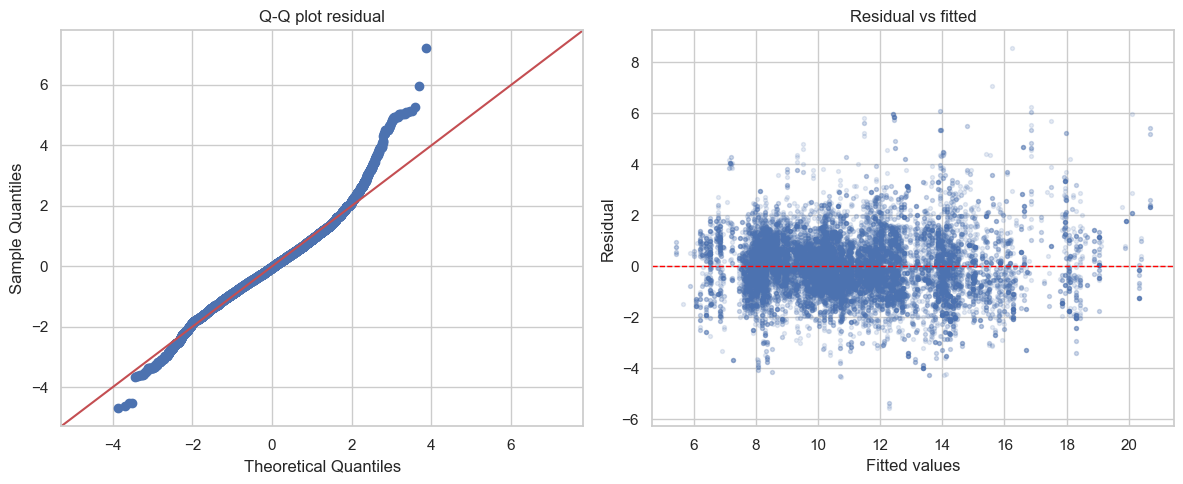

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(resid, line='45', fit=True, ax=axes[0])
axes[0].set_title('Q-Q plot residual')
axes[1].scatter(fitted, resid, alpha=0.15, s=8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs fitted')
fig.tight_layout()
plt.show()

**Diagnostik visual**:
- Q-Q plot: bagian tengah mengikuti garis 45 derajat, dengan penyimpangan terkumpul di ekor. Ini pola yang umum untuk respons yang sedikit condong dan masih wajar.
- Residual vs fitted: titik-titik berpita di sekitar nol membentuk melebar seperti corong menandakan heteroskedastisitas (konsisten dengan Breusch-Pagan), sedangkan lengkungan sistematis akan menandakan nonlinearitas. Spesifikasi linear tampak memadai.
- Kesimpulan: heteroskedastisitas (corong pada residual vs fitted) ditangani pada tahap Refinement dengan standard error robust HC3 sehingga inferensi per koefisien tetap valid. Non-normalitas tidak fatal untuk prediksi titik (Central Limit Theorem), tetapi masih memengaruhi kalibrasi interval prediksi, yang diuraikan pada Kesimpulan.

## Refinement dan Interpretasi

### 19. Ablasi: Kontribusi `cylinders` dan `year`

`engine_size` dan `cylinders` sangat kolinier ($r \approx 0.91$), sehingga koefisiennya sulit ditafsirkan sendiri-sendiri. Namun untuk model prediktif pertanyaannya adalah apakah `cylinders` menambah daya prediksi di atas `engine_size`? Pertanyaan ini dapat jawab dengan membandingkan model lengkap dengan model tanpa `cylinders` pada data test.

In [92]:
feat_no_cyl = [c for c in feature_cols if c != 'cylinders']
Xtr_nc = sm.add_constant(X_train[feat_no_cyl]).astype(float)
Xte_nc = sm.add_constant(X_test[feat_no_cyl], has_constant='add').astype(float)
m_no_cyl = sm.OLS(y_train, Xtr_nc).fit()

r2t_full = r2_score(y_test, model.predict(X_test_c))
r2t_nc = r2_score(y_test, m_no_cyl.predict(Xte_nc))
abla = pd.DataFrame(
    {'R2_train': [model.rsquared, m_no_cyl.rsquared], 'R2_test': [r2t_full, r2t_nc]},
    index=['dengan cylinders', 'tanpa cylinders'],
)
print(f'Kontribusi cylinders pada R^2 test: {r2t_full - r2t_nc:+.4f}')
abla.round(4)

Kontribusi cylinders pada R^2 test: +0.0197


,R2_train,R2_test
dengan cylinders,0.8342,0.8365
tanpa cylinders,0.8164,0.8168


**Hasil ablasi**:
- Membuang `cylinders` menurunkan $R^2$ uji sekitar $0.02$. Penurunan yang konsisten pada data test (bukan hanya train) menandakan informasi itu nyata, bukan overfitting.
- Jadi `cylinders` menyumbang daya prediksi di luar `engine_size`: kolinier bukan berarti redundan. Inilah alasan empiris mempertahankan keduanya, dengan koefisien ditafsirkan bersama.

Pada Fase 1 `year` dibuang karena korelasi marginalnya dengan `comb_l_100km` mendekati nol ($|r| < 0.07$). Korelasi itu memang signifikan secara statistik, tetapi hanya karena ukuran sampel besar ($n$ sekitar 22 ribu) membuat uji `pearsonr` menolak $H_0: \rho = 0$ bahkan untuk korelasi yang dapat diabaikan. Signifikansi statistik di sini bukan tanda relevansi praktis. Karena itu kita tidak menilai `year` dari p-value korelasinya, melainkan dari kontribusi prediktifnya: dengan standar held-out yang sama seperti `cylinders`, apakah menambahkan `year` ke model menaikkan $R^2$ uji setelah prediktor lain dikontrol? Ini menguji kontribusi *kondisional*, bukan asosiasi marginal.

In [93]:
year_full = raw['YEAR']
Xtr_yr = sm.add_constant(X_train.assign(year=year_full.loc[X_train.index])).astype(float)
Xte_yr = sm.add_constant(X_test.assign(year=year_full.loc[X_test.index]), has_constant='add').astype(float)
m_yr = sm.OLS(y_train, Xtr_yr).fit()

r2t_year = r2_score(y_test, m_yr.predict(Xte_yr))
abla_year = pd.DataFrame(
    {'R2_train': [model.rsquared, m_yr.rsquared], 'R2_test': [r2t_full, r2t_year]},
    index=['tanpa year (final)', 'dengan year'],
)
print(f'Kontribusi year pada R^2 test: {r2t_year - r2t_full:+.4f}')
print(f'Koefisien year: {m_yr.params["year"]:+.5f}  (p = {m_yr.pvalues["year"]:.3f})')
abla_year.round(4)

Kontribusi year pada R^2 test: -0.0000
Koefisien year: +0.00042  (p = 0.852)


,R2_train,R2_test
tanpa year (final),0.8342,0.8365
dengan year,0.8342,0.8365


**Hasil ablasi `year`**:
- Menambahkan `year` praktis tidak mengubah $R^2$ uji ($\approx 0.000$) dan koefisiennya tidak signifikan ($p$ tinggi).
- Jadi `year` tidak hanya berkorelasi marginal $\approx 0$, tetapi juga tidak menyumbang daya prediksi secara kondisional setelah ukuran mesin, kelas, bahan bakar, dan transmisi dikontrol. Keputusan membuangnya di Fase 1 terkonfirmasi dengan standar held-out yang sama seperti `cylinders`.

### 20. Refinement Inferensi: Standard Error Robust (HC3)

Validasi asumsi mengonfirmasi heteroskedastisitas (Breusch-Pagan + pola corong pada residual). Ini tidak membiaskan estimasi titik koefisien, tetapi membuat standard error OLS klasik keliru sehingga p-value dan confidence interval tidak dapat dipercaya. Disini standard error klasik diganti dengan **heteroskedasticity-consistent (HC) standard error** yang tidak mengasumsikan varians error konstan. Estimasi titik koefisien tetap identik, hanya ketidakpastiannya yang dikoreksi.

Varian **HC3** digunakan karena merupakan varian yang paling konservatif dibandingkan varian HC lainnya HC1 sehingga SE tidak pernah terlalu optimis. Pada $n$ besar seperti data kita selisih antar-varian hampir nol, jadi memilih yang paling aman tidak ada ruginya.

In [94]:
model_ols = model
model_hc3 = sm.OLS(y_train, X_train_c).fit(cov_type='HC3')

se_cmp = pd.DataFrame({'SE_OLS': model_ols.bse, 'SE_HC3': model_hc3.bse})
se_cmp['rasio_HC3/OLS'] = se_cmp['SE_HC3'] / se_cmp['SE_OLS']

sampel = ['engine_size', 'cylinders', 'fuel_Premium gasoline (Z)', 'vehicle_class_VAN PASSENGER']
print('Standard error: OLS klasik vs robust HC3 (sampel koefisien)')
print(se_cmp.loc[sampel].round(4).to_string())

model = model_hc3

Standard error: OLS klasik vs robust HC3 (sampel koefisien)
                             SE_OLS  SE_HC3  rasio_HC3/OLS
engine_size                  0.0185  0.0264         1.4307
cylinders                    0.0131  0.0185         1.4108
fuel_Premium gasoline (Z)    0.0782  0.0574         0.7337
vehicle_class_VAN PASSENGER  0.0859  0.1053         1.2251


**Hasil:**
- SE OLS klasik dan HC3 berbeda nyata pada sebagian koefisien (mis. `engine_size` dan `cylinders` naik sekitar 40%, sedangkan beberapa dummy bahan bakar justru turun). Ini bukti langsung bahwa SE klasik kurang akurat saat ada heteroskedastisitas, sehingga memakai SE robust HC3 adalah koreksi yang tepat.

### 21. Final Coefficient Report

Tabel   final coefficient beserta standard error, p-value, dan confidence interval 95% (semuanya berbasis kovarians robust HC3). Koefisien yang confidence intervalnya tidak melewati nol berbeda signifikan dari nol.

In [95]:
conf = model.conf_int().rename(columns={0: 'CI_low_95', 1: 'CI_high_95'})
report = pd.DataFrame({
    'coef': model.params,
    'std_err': model.bse,
    'p_value': model.pvalues,
    'CI_low_95': conf['CI_low_95'],
    'CI_high_95': conf['CI_high_95'],
})
report.round(4)

,coef,std_err,p_value,CI_low_95,CI_high_95
const,3.1407,0.0868,0.0000,2.9706,3.3108
engine_size,0.6438,0.0264,0.0000,0.5920,0.6955
cylinders,0.5740,0.0185,0.0000,0.5378,0.6102
n_gears,-0.0518,0.0075,0.0000,-0.0664,-0.0371
fuel_Ethanol E85 (E),5.4887,0.0758,0.0000,5.3401,5.6373
fuel_Natural gas (N),3.7854,0.2542,0.0000,3.2871,4.2837
fuel_Premium gasoline (Z),2.0951,0.0574,0.0000,1.9827,2.2076
fuel_Regular gasoline (X),1.4221,0.0569,0.0000,1.3105,1.5336
vehicle_class_FULL SIZE,0.0155,0.0435,0.7212,-0.0698,0.1008
vehicle_class_MID SIZE,0.0016,0.0304,0.9576,-0.0580,0.0612


**Interpretasi:**
- Seluruh prediktor numerik dan mayoritas dummy bahan bakar, kelas kendaraan, serta transmisi signifikan (CI tidak berpotongan dengan nol).
- Beberapa kategori kecil yang mendekati COMPACT bisa tidak signifikan. Hal ini masih dianggap wajar, menandakan kelas tersebut tidak berbeda dari referensi.
- Standard error, p-value, dan confidence interval berbasis kovarians robust HC3, jadi sudah tahan terhadap heteroskedastisitas.

## Kesimpulan

In [96]:
train_pred = model.predict(X_train_c)
test_pred = model.predict(X_test_c)

print('=' * 66)
print('RINGKASAN ANALISIS')
print('=' * 66)
print(f'Model         : Regresi linear berganda + one-hot encoding')
print(f'Prediktor     : {num_cols} + one-hot{tuple(cat_cols)}')
print(f'Total fitur   : {len(feature_cols)} (+ konstanta)')
print(f'Dibuang       : year (korelasi ~0), kolom `comb_l_100km`/emisi lain (bocor ke target)')
print()
print(f'R^2  train/test : {r2_score(y_train, train_pred):.4f} / {r2_score(y_test, test_pred):.4f}')
print(f'RMSE test       : {np.sqrt(mean_squared_error(y_test, test_pred)):.4f} L/100 km')
print(f'MAE  test       : {mean_absolute_error(y_test, test_pred):.4f} L/100 km')
print()
print('Asumsi : heteroskedastik (BP) -> dikoreksi dgn standard error robust HC3;')
print('         non-normal (JB) -> inferensi titik aman (CLT), interval prediksi kurang terkalibrasi;')
print('         independensi diasumsikan (data cross-sectional).')
print('=' * 66)

RINGKASAN ANALISIS
Model         : Regresi linear berganda + one-hot encoding
Prediktor     : ['engine_size', 'cylinders', 'n_gears'] + one-hot('fuel', 'vehicle_class', 'transmission_type')
Total fitur   : 27 (+ konstanta)
Dibuang       : year (korelasi ~0), kolom `comb_l_100km`/emisi lain (bocor ke target)

R^2  train/test : 0.8342 / 0.8365
RMSE test       : 1.1757 L/100 km
MAE  test       : 0.8941 L/100 km

Asumsi : heteroskedastik (BP) -> dikoreksi dgn standard error robust HC3;
         non-normal (JB) -> inferensi titik aman (CLT), interval prediksi kurang terkalibrasi;
         independensi diasumsikan (data cross-sectional).


**Kesimpulan**:
- Multiple linear regression dengan one-hot encoding pada jenis bahan bakar, kelas kendaraan, dan transmisi menjelaskan $\approx 84\%$ variance `comb_l_100km` bahan bakar gabungan, dan menggeneralisasi baik ($R^2$ train dan test berdekatan, tanpa overfitting).
- Penggerak utama: jenis bahan bakar (Diesel paling hemat, Ethanol/Natural Gas paling boros), kelas kendaraan (gradien dari mobil kecil ke van/pikap/SUV), dan ukuran mesin (`engine_size` bersama `cylinders`). `n_gears` dan tipe transmisi berpengaruh lebih kecil (CVT paling hemat). Suku kuadratik `engine_size`$^2$ sempat diuji (bagian 15) tetapi tidak menambah $R^2$ test, jadi model linear yang lebih sederhana dipilih.

**Keterbatasan dari asumsi yang dilanggar**:
- Heteroskedastisitas (error variance tidak konstan, terkonfirmasi Breusch-Pagan): estimasi titik koefisien dan prediksi tetap *unbiased*. Standard error OLS biasa akan keliru, maka kami memakai standard error robust HC3 (White). p-value dan confidence interval yang dilaporkan sudah dikoreksi terhadap heteroskedastisitas dan dapat ditafsirkan sebagaimana mestinya.
- Non-normalitas residual (condong ke kanan dengan heavy tail, terkonfirmasi Jarque-Bera): inferensi koefisien tetap valid dengan pendekatan approximation berkat $n$ besar (Central Limit Theorem), namun interval prediksi yang mengasumsikan error normal menjadi tidak terkalibrasi, terutama di tail. Kesalahan ekstrem lebih sering daripada yang diperkirakan model normal.
- Independensi tidak diuji (data cross-sectional) memungkinkan korelasi dalam-grup antar varian dari model kendaraan yang sama dapat membuat standard error terlalu optimis. HC3 mengoreksi heteroskedastisitas tetapi tidak korelasi dalam-grup sehingga menanganinya memerlukan standard error berbasis cluster (mis. `cov_type='cluster'`) dengan pengelompokan per model kendaraan.
- Konsekuensi praktis: model andal untuk prediksi titik, untuk arah dan peringkat pengaruh antar faktor, dan berkat standard error robust HC3 untuk inferensi signifikansi per koefisien. Yang masih belum terkalibrasi adalah interval prediksi (akibat non-normalitas) serta kemungkinan korelasi dalam-grup. Model juga bersifat asosiatif, bukan kausal.